In [1]:
%%capture
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# import Scribe as sb
import sys
import os

# import scanpy as sc
import dynamo as dyn
import seaborn as sns

dyn.dynamo_logger.main_silence()
dyn.configuration.set_figure_params('dynamo', background='white')

In [5]:
adata_labeling = dyn.sample_data.hematopoiesis()

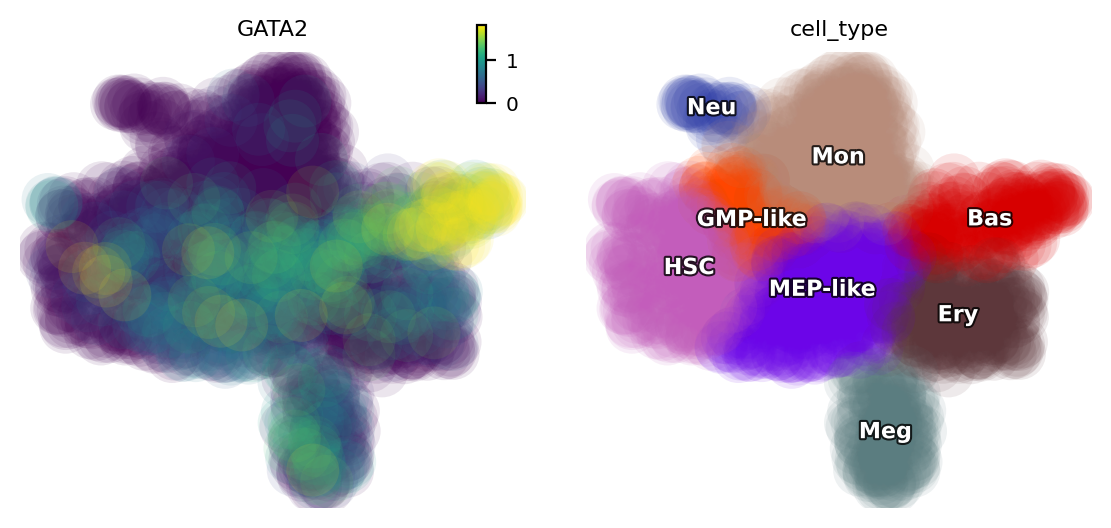

In [3]:
dyn.pl.scatters(adata_labeling, 
                color=["GATA2", "cell_type"],
               figsize=(4,3))


Transforming subset Jacobian: 100%|██████████| 1947/1947 [00:00<00:00, 105261.73it/s]


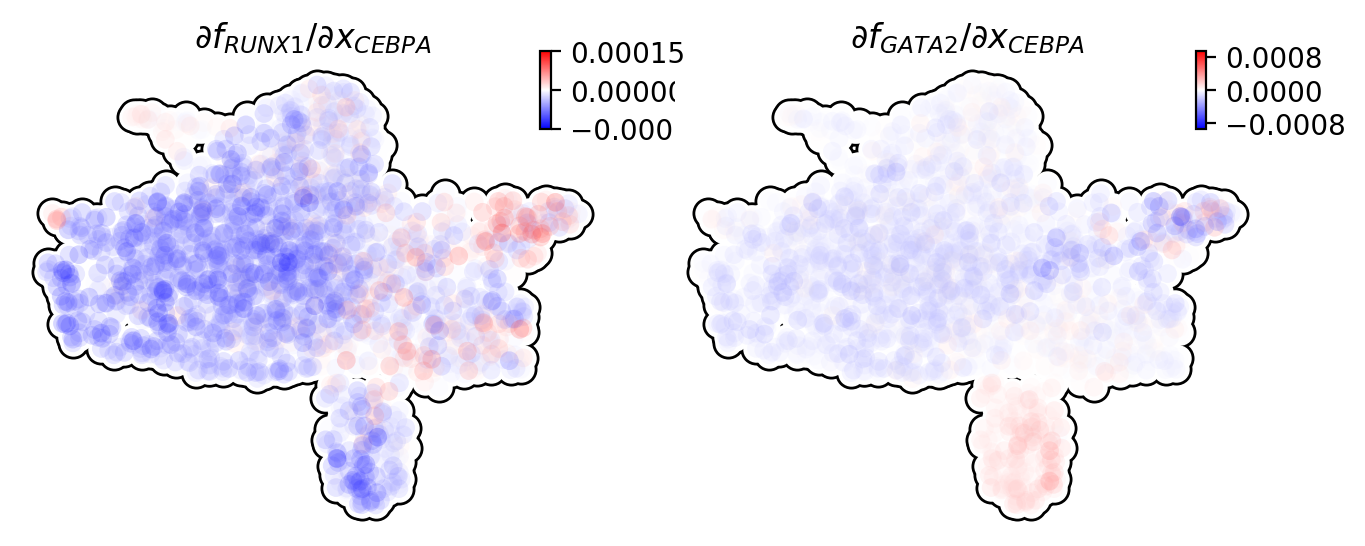

In [47]:
selected_genes = ["GATA2", "CEBPA", "RUNX1",'SPI1']

dyn.vf.jacobian(adata_labeling, regulators=selected_genes, effectors=selected_genes)
dyn.pl.jacobian(
    adata_labeling,
    regulators="CEBPA",
    effectors=["RUNX1", "GATA2"],
    basis="umap",
    figsize=(4,3)
)


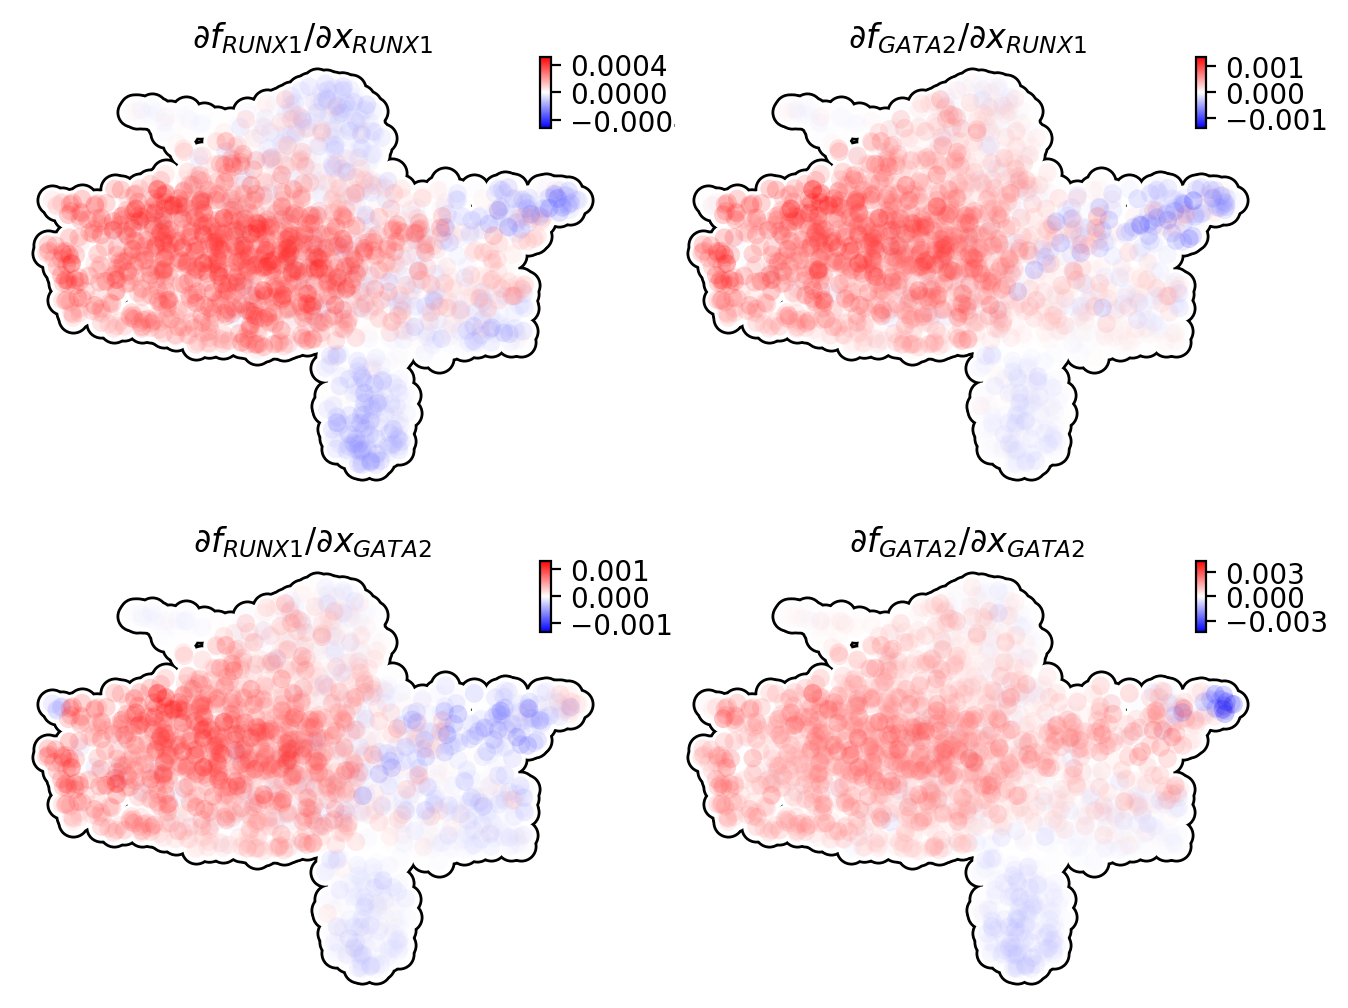

In [49]:
dyn.pl.jacobian(
    adata_labeling,
    effectors=["RUNX1", "GATA2"],
    basis="umap",
    figsize=(4,3)
)


In [50]:
adata=adata_labeling
jkey='jacobian'
j_basis='pca'

In [51]:
Jacobian_ = jkey if j_basis is None else jkey + "_" + j_basis
Der, cell_indx, jacobian_gene, regulators_, effectors_ = (
    adata.uns[Jacobian_].get(jkey.split("_")[-1]),
    adata.uns[Jacobian_].get("cell_idx"),
    adata.uns[Jacobian_].get(jkey.split("_")[-1] + "_gene"),
    adata.uns[Jacobian_].get("regulators"),
    adata.uns[Jacobian_].get("effectors"),
)

In [52]:
regulators=["CEBPA",'RUNX1','GATA2','SPI1']
effectors=["RUNX1", "GATA2",'SPI1']

In [53]:
from dynamo.vectorfield.utils import intersect_sources_targets

In [54]:
if regulators is None and effectors is not None:
    regulators = effectors
elif effectors is None and regulators is not None:
    effectors = regulators
# test the simulation data here
if regulators_ is None or effectors_ is None:
    if Der.shape[0] != adata_.n_vars:
        source_genes = [j_basis + "_" + str(i) for i in range(Der.shape[0])]
        target_genes = [j_basis + "_" + str(i) for i in range(Der.shape[1])]
    else:
        source_genes, target_genes = adata_.var_names, adata_.var_names
else:
    Der, source_genes, target_genes = intersect_sources_targets(
        regulators,
        regulators_,
        effectors,
        effectors_,
        Der if jacobian_gene is None else jacobian_gene,
    )

In [55]:
prefix = "X_"
basis='umap'
x=0
y=1
adata_=adata
cur_pd = pd.DataFrame(
    {
        basis + "_" + str(x): adata_.obsm[prefix + basis][:, x],
        basis + "_" + str(y): adata_.obsm[prefix + basis][:, y],
    }
)

In [56]:
for i, source in enumerate(source_genes):
    for j, target in enumerate(target_genes):
        J = Der[j, i, :]  # dim 0: target; dim 1: source
        cur_pd[f"jacobian_{target}_{source}"] = J
cur_pd

,umap_0,umap_1,jacobian_SPI1_SPI1,jacobian_RUNX1_SPI1,jacobian_GATA2_SPI1,jacobian_SPI1_RUNX1,jacobian_RUNX1_RUNX1,jacobian_GATA2_RUNX1,jacobian_SPI1_GATA2,jacobian_RUNX1_GATA2,jacobian_GATA2_GATA2,jacobian_SPI1_CEBPA,jacobian_RUNX1_CEBPA,jacobian_GATA2_CEBPA
0,14.861850,11.734772,0.000011,-0.000050,-0.000093,-0.000035,0.000117,0.000472,-0.000012,0.000103,0.001599,0.000034,-0.000065,-1.439301e-04
1,14.442189,5.475870,-0.000003,0.000004,0.000054,0.000007,-0.000190,-0.000216,0.000008,-0.000150,-0.000870,-0.000010,-0.000079,1.105365e-04
2,13.545568,12.149780,0.000009,-0.000039,-0.000037,-0.000020,0.000015,-0.000054,-0.000017,-0.000028,0.001526,0.000013,-0.000026,-1.235153e-05
3,11.290036,13.999574,0.000011,-0.000042,-0.000167,-0.000021,0.000085,0.000586,-0.000104,0.000473,0.001213,0.000019,-0.000049,4.945379e-07
4,13.896807,10.105231,0.000003,-0.000024,-0.000033,-0.000034,0.000193,0.000107,-0.000009,0.000005,0.000600,0.000020,-0.000069,-2.180513e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,11.630127,9.695171,0.000010,-0.000044,-0.000111,-0.000014,0.000009,0.000360,-0.000074,0.000360,0.000620,0.000022,-0.000067,2.716803e-05
1943,11.894936,8.359780,0.000002,-0.000045,-0.000068,-0.000004,0.000085,0.000277,-0.000015,0.000201,0.000569,0.000015,-0.000050,-2.105353e-04
1944,11.728176,8.699327,-0.000005,-0.000007,-0.000004,0.000008,-0.000140,-0.000082,0.000025,-0.000236,-0.000829,-0.000011,-0.000001,1.141922e-05
1945,16.423391,10.643045,-0.000012,0.000057,-0.000358,0.000007,-0.000113,0.000080,0.000026,-0.000111,-0.000216,-0.000008,0.000034,-4.530321e-04


In [57]:
for i, source in enumerate(source_genes):
    for j, target in enumerate(target_genes):
        adata.obs[f'jacobian_{target}_{source}']=cur_pd[f'jacobian_{target}_{source}'].values.reshape(-1)

In [58]:
adata.obs['jacobian_GATA2_CEBPA']=cur_pd['jacobian_GATA2_CEBPA'].values.reshape(-1)

In [59]:
import omicverse as ov
fig,ax=plt.subplots(1,1,figsize = (3,3))
ov.pl.embedding(adata,
               basis='X_umap',
               color='jacobian_RUNX1_CEBPA',
               show=False,
               ax=ax)

<AxesSubplot: title={'center': 'jacobian_RUNX1_CEBPA'}, xlabel='X_umap1', ylabel='X_umap2'>

(3.7524107440563226, 8.706780527357472)

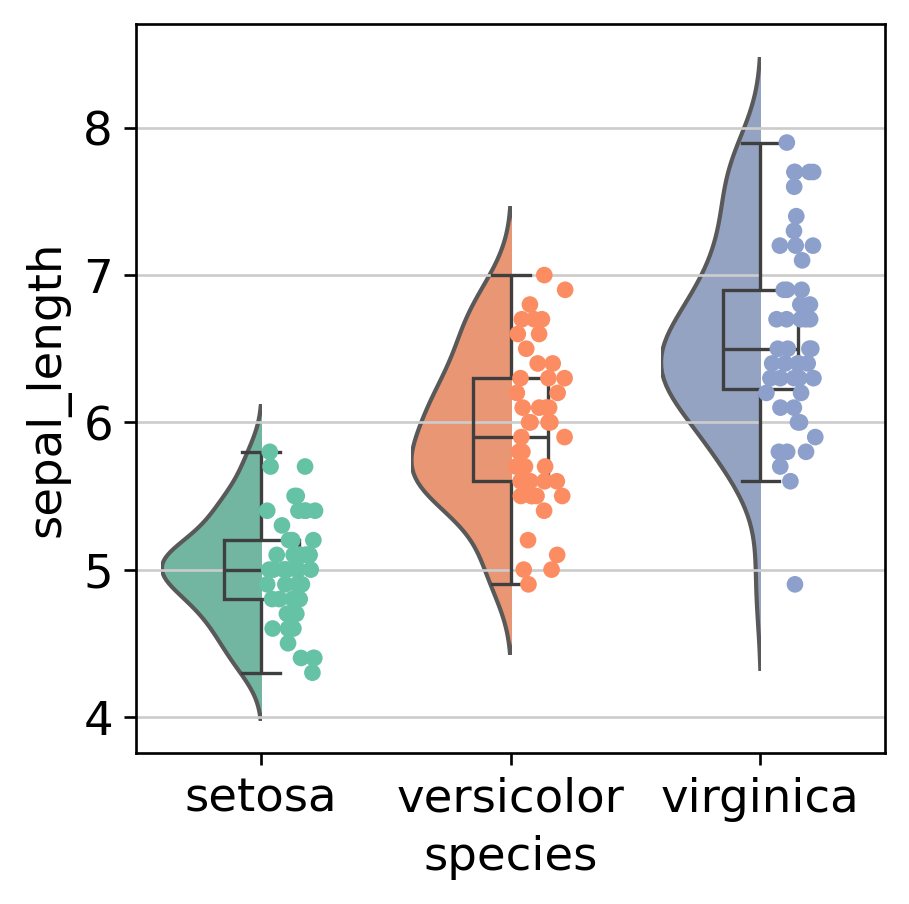

In [24]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
iris = sns.load_dataset('iris')
palette = 'Set2'
ax = sns.violinplot(x="species", y="sepal_length", data=iris, hue="species", dodge=False,
                    palette=palette,
                    scale="width", inner=None)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
for violin in ax.collections:
    bbox = violin.get_paths()[0].get_extents()
    x0, y0, width, height = bbox.bounds
    violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))

sns.boxplot(x="species", y="sepal_length", data=iris, saturation=1, showfliers=False,
            width=0.3, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)
old_len_collections = len(ax.collections)
sns.stripplot(x="species", y="sepal_length", data=iris, hue="species", palette=palette, dodge=False, ax=ax)
for dots in ax.collections[old_len_collections:]:
    dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))
ax.set_xlim(xlim)
ax.set_ylim(ylim)

In [25]:
adata_labeling.raw is None

True

In [26]:
adata_labeling.raw=adata_labeling

In [27]:
adata_labeling.raw[:,'GATA2'].X.toarray().reshape(-1)

array([0.        , 0.71029127, 0.        , ..., 0.        , 1.9224846 ,
       0.        ], dtype=float32)

In [28]:
adata_labeling.obs['nGenes'].values.reshape(-1)

array([1196, 1172,  663, ...,  642,  656,  819])

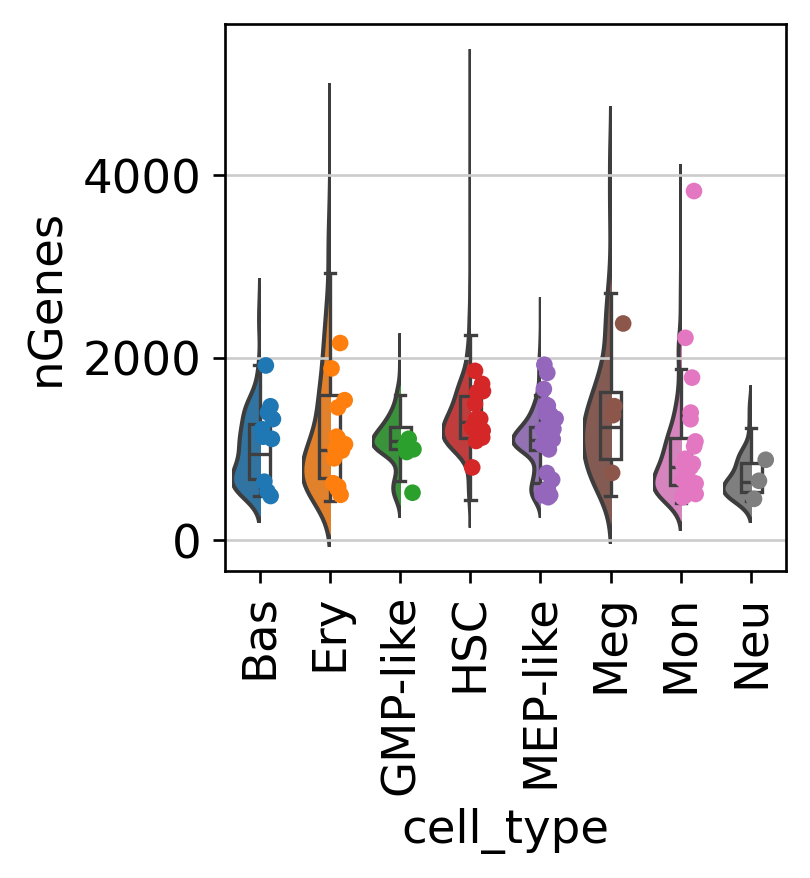

<AxesSubplot: xlabel='cell_type', ylabel='nGenes'>

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import issparse

def violin_box(adata, keys, groupby, ax=None, figsize=(4,4), 
               size=5,
               show=True, max_strip_points=1000):
    import colorcet
    
    # 获取 y 数据
    y = None
    if not adata.raw is None and keys in adata.raw.var_names:
        y = adata.raw[:, keys].X
    elif keys in adata.obs.columns:
        y = adata.obs[keys].values
    elif keys in adata.var_names:
        y = adata[:, keys].X
    else:
        raise ValueError(f'{keys} not found in adata.raw.var_names, adata.var_names, or adata.obs.columns')
    
    if issparse(y):
        y = y.toarray().reshape(-1)
    else:
        y = y.reshape(-1)
    
    # 获取 x 数据
    x = adata.obs[groupby].values.reshape(-1)
    
    # 创建绘图数据
    plot_data = pd.DataFrame({groupby: x, keys: y})
    
    # 创建图形和轴
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # 获取或设置颜色
    if f'{groupby}_colors' not in adata.uns or adata.uns[f'{groupby}_colors'] is None:
        colors = ['#%02x%02x%02x' % tuple([int(k * 255) for k in i]) for i in colorcet.glasbey_bw_minc_20_maxl_70]
        adata.uns[f'{groupby}_colors'] = colors[:len(adata.obs[groupby].unique())]
    
    # 绘制小提琴图
    sns.violinplot(x=groupby, y=keys, data=plot_data, hue=groupby, dodge=False,
                   palette=adata.uns[f'{groupby}_colors'], scale="width", inner=None, ax=ax)
    
    # 调整小提琴图
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    for violin in ax.collections:
        bbox = violin.get_paths()[0].get_extents()
        x0, y0, width, height = bbox.bounds
        violin.set_clip_path(plt.Rectangle((x0, y0), width / 2, height, transform=ax.transData))
    
    # 绘制箱线图
    sns.boxplot(x=groupby, y=keys, data=plot_data, saturation=1, showfliers=False,
                width=0.3, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)
    
    # 限制 stripplot 的数据点数量
    if len(plot_data) > max_strip_points:
        plot_data = plot_data.sample(max_strip_points)
    
    # 绘制 stripplot
    old_len_collections = len(ax.collections)
    sns.stripplot(x=groupby, y=keys, data=plot_data, hue=groupby,size=size,
                  palette=adata.uns[f'{groupby}_colors'], dodge=False, ax=ax)
    
    # 调整 stripplot 点的位置
    for dots in ax.collections[old_len_collections:]:
        dots.set_offsets(dots.get_offsets() + np.array([0.12, 0]))
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    plt.xticks(rotation=90)
    
    if show:
        plt.show()
    
    return ax
fig,ax=plt.subplots(1,1,figsize = (3,3))
violin_box(adata_labeling,keys="nGenes",groupby='cell_type',ax=ax,
          max_strip_points=100)

In [30]:
adata_labeling.obs['cell_type'].cat.categories

Index(['Bas', 'Ery', 'GMP-like', 'HSC', 'MEP-like', 'Meg', 'Mon', 'Neu'], dtype='object')

In [31]:
import omicverse as ov
ov.plot_set()
fb=ov.pl.ForbiddenCity()

Dependency error: The 'phate>=1.0' distribution was not found and is required by the application


In [32]:
from IPython.display import HTML
HTML(fb.visual_color(loc_range=(0,384),
                    num_per_row=24))

人籁,青粲,翠缥,水龙吟,碧山,石发,菉竹,庭芜绿,葱倩,漆姑,翠微,芰荷,青青,翠虬,官绿,油绿,莓莓,螺青,春辰,麴尘,欧碧,苍葭,兰苕,青玉案
,,,,,,,,,,,,,,,,,,,,,,,
碧滋,瓷秘,筠雾,竹香子,鸣珂,琬琰,出岫,王刍,春碧,执大象,青圭,绿沈,风入松,荩篋,绞衣,素綦,苍筤,天缥,卵色,沧浪,葭菼,山岚,冰台,青古
,,,,,,,,,,,,,,,,,,,,,,,
醽醁,渌波,青楸,缥碧,翠涛,青梅,雀梅,苔古,蕉月,干山翠,翕赩,结绿,绿云,丹罽,黄丹,檎丹,银朱,洛神珠,珊瑚赫,朱孔阳,丹雘,水华朱,胭脂虫,朱樱
,,,,,,,,,,,,,,,,,,,,,,,
大繎,顺圣,爵头,麒麟竭,苕荣,扶光,十样锦,海天霞,驿刚,朱颜酡,赦霞,赦尾,缙云,小红,琼琚,岱赭,朱柿,艳炽,鹤顶红,赤缇,纁黄,棠梨,朱殷,石榴裙
,,,,,,,,,,,,,,,,,,,,,,,
朱草,赤灵,佛赤,綪茷,朱湛,丹秫,木兰,杨妃,盈盈,银红,粉米,桃夭,水红,夕岚,彤管,咸池,莲红,雌霓,縓缘,长春,渥赭,红䵂,紫梅,绛纱
,,,,,,,,,,,,,,,,,,,,,,,
茹藘,美人祭,唇脂,牙绯,鞓红,葡萄褐,蚩尤旗,紫矿,紫诰,苏方,霁红,蜜褐,福色,黪紫,龙膏烛,苏梅,琅环紫,胭脂水,紫茎屏风,红踯躅,胭脂紫,魏红,紫府,魏紫


In [33]:
color_dict={
    'Bas':fb.get_color(name='朱樱')['color_html'].values[0], 
    'Ery':fb.get_color(name='二绿')['color_html'].values[0], 
    'GMP-like':fb.get_color(name='魏红')['color_html'].values[0], 
    'HSC':fb.get_color(name='盈盈')['color_html'].values[0], 
    'MEP-like':fb.get_color(name='杨妃')['color_html'].values[0], 
    'Meg':fb.get_color(name='群青')['color_html'].values[0], 
    'Mon':fb.get_color(name='赪紫')['color_html'].values[0], 
    'Neu':fb.get_color(name='凝夜紫')['color_html'].values[0], 
    
}

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


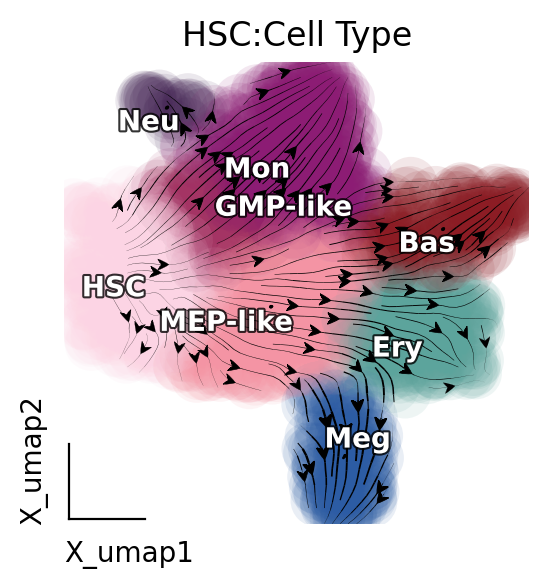

In [107]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(adata_labeling, color=['cell_type'], 
                       color_key=color_dict,
                       #title='DG:CellType',
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=0.5,
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title('HSC:Cell Type',fontsize=12)
coords=adata_labeling.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)


fig.savefig(f'figures/fig4/dynamo_HSC_Velo.png', dpi=300, bbox_inches='tight')

In [76]:
dyn.pl.scatters?

Signature:
dyn.pl.scatters(
    adata: anndata._core.anndata.AnnData,
    basis: str = 'umap',
    x: int = 0,
    y: int = 1,
    z: int = 2,
    color: str = 'ntr',
    layer: str = 'X',
    highlights: Optional[list] = None,
    labels: Optional[list] = None,
    values: Optional[list] = None,
    theme: Optional[Literal['blue', 'red', 'green', 'inferno', 'fire', 'viridis', 'darkblue', 'darkred', 'darkgreen']] = None,
    cmap: Optional[str] = None,
    color_key: Union[Dict[str, str], List[str], NoneType] = None,
    color_key_cmap: Optional[str] = None,
    background: Optional[str] = None,
    ncols: int = 4,
    pointsize: Optional[float] = None,
    figsize: Tuple[float, float] = (6, 4),
    show_legend: str = 'on data',
    use_smoothed: bool = True,
    aggregate: Optional[str] = None,
    show_arrowed_spines: bool = False,
    ax: Optional[matplotlib.axes._axes.Axes] = None,
    sort: Literal['raw', 'abs', 'neg'] = 'raw',
    save_show_or_return: Literal['save', 'show', 'ret

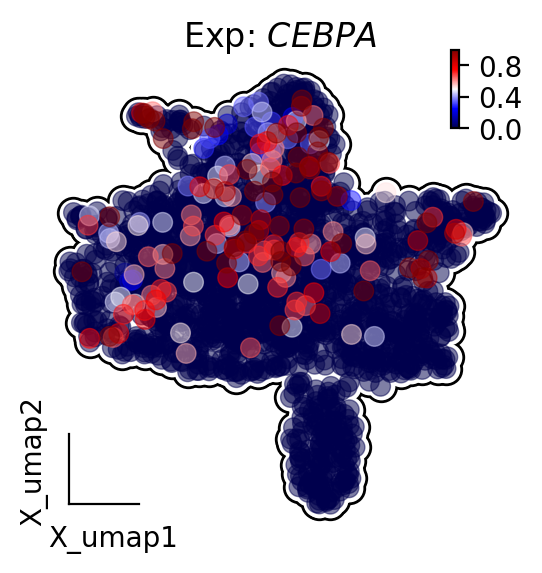

In [112]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
gene='CEBPA'
dyn.pl.scatters(adata_labeling, color=[gene], 
                       #color_key=color_dict,
                       #title='DG:CellType',
                       basis='umap', 
                cmap='seismic',
                alpha=0.5,
                        s=50,
                        frontier=True,
                       linewidth=0.5,
                        #vmax=0.5,
                    #vmax='p99.2',
                       #show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
ax.set_title(r'Exp: ${%s}$' % gene,fontsize=12)
coords=adata_labeling.obsm['X_umap']
xmin=coords[:, 0].min()
xmax=coords[:, 0].max()
ymin=coords[:, 1].min()
ymax=coords[:, 1].max()

#ax.spines['left'].set_position(('outward', 10))
#ax.spines['bottom'].set_position(('axes', 0))
ax.spines['left'].set_position(('data', xmin))
ax.spines['bottom'].set_position(('data', ymin))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines["bottom"].set_visible(True)
ax.spines["left"].set_visible(True)

ax.get_xaxis().set_visible(True)
ax.get_yaxis().set_visible(True)
ax.set_yticks([])
ax.set_xticks([])
ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
axis_labels=['X_umap1','X_umap2']
ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)

fig.savefig(f'figures/fig4/exp_HSC_{gene}.png', dpi=300, bbox_inches='tight')

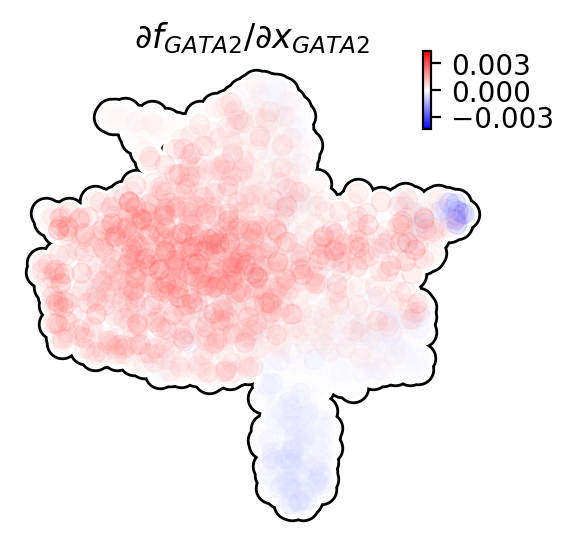

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
target='GATA2'
source='GATA2'
v_max = np.max(np.abs(adata_labeling.obs[f"jacobian_{target}_{source}"]))
dyn.pl.scatters(adata_labeling, color=[f"jacobian_{target}_{source}"], 
                       #color_key=color_dict,
                       #title='DG:CellType',
                       basis='umap', 
                       linewidth=0.5,
                       vmin=-v_max,
                        vmax=v_max,
                        cmap='bwr',s=50,
                        frontier=True,
                      save_show_or_return='return',ax=ax)
ax.set_title(r"$\partial f_{%s} / \partial x_{%s}$" % (target, source),fontsize=12)
fig.savefig(f'figures/fig4/umap_jacobian_HSC_{target}_{source}.png', dpi=300, bbox_inches='tight')

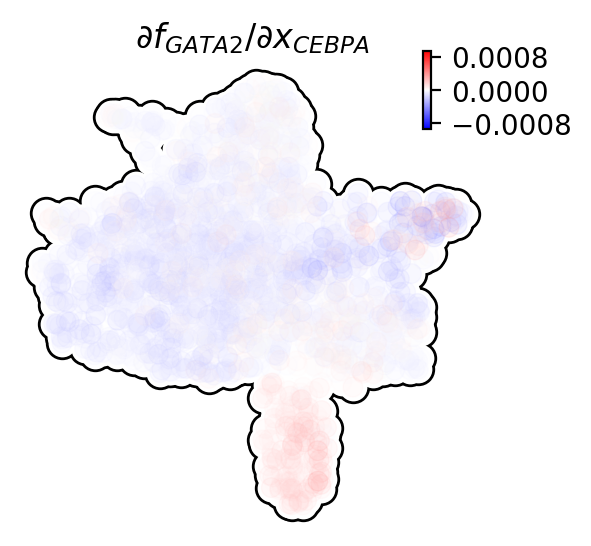

In [38]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
target='GATA2'
source='CEBPA'
v_max = np.max(np.abs(adata_labeling.obs[f"jacobian_{target}_{source}"]))
dyn.pl.scatters(adata_labeling, color=[f"jacobian_{target}_{source}"], 
                       #color_key=color_dict,
                       #title='DG:CellType',
                       basis='umap', 
                       linewidth=0.5,
                       vmin=-v_max,
                        vmax=v_max,
                        cmap='bwr',s=50,
                        frontier=True,
                      save_show_or_return='return',ax=ax)
ax.set_title(r"$\partial f_{%s} / \partial x_{%s}$" % (target, source),fontsize=12)
fig.savefig(f'figures/fig4/umap_jacobian_HSC_{target}_{source}.png', dpi=300, bbox_inches='tight')

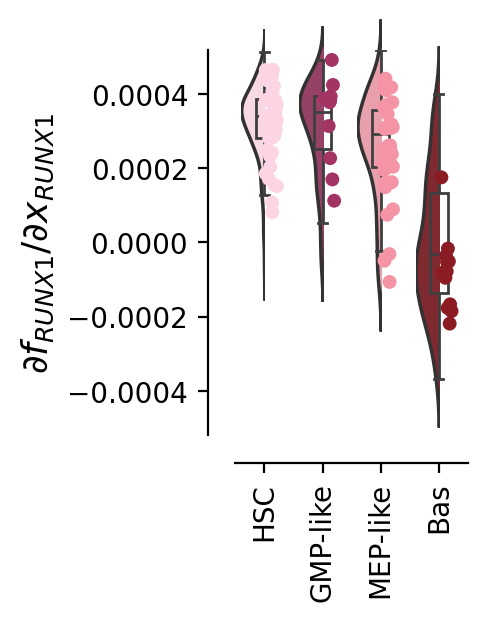

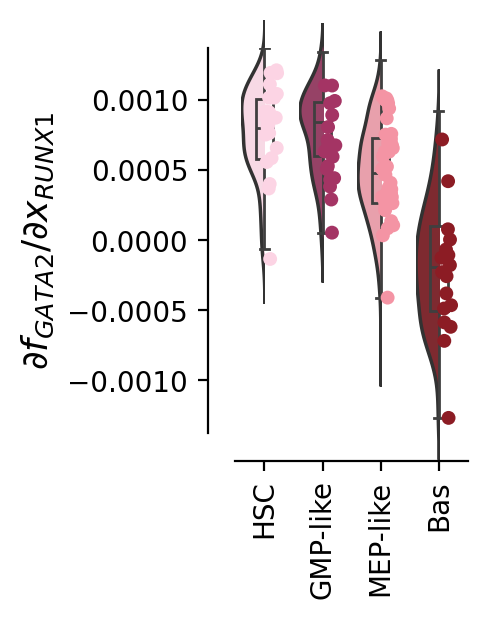

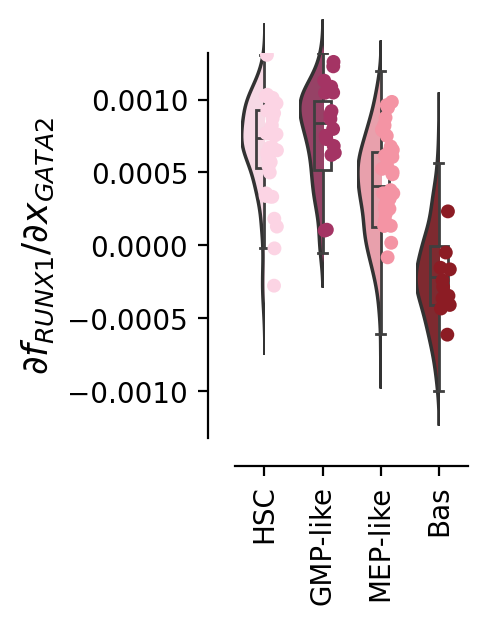

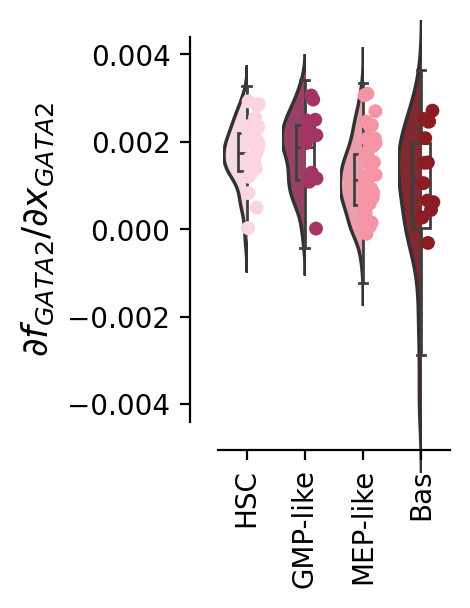

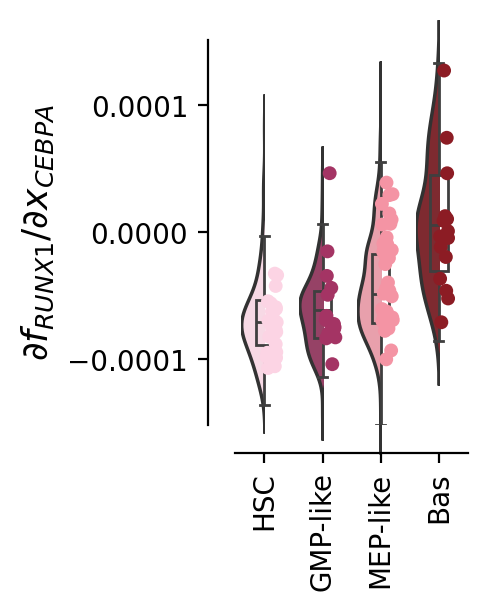

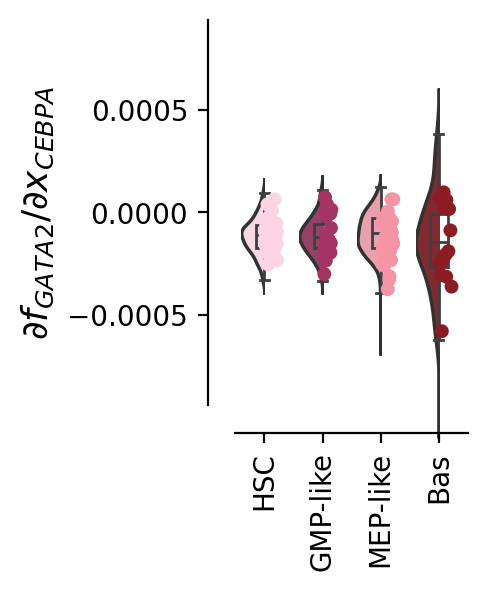

In [39]:
%matplotlib inline

for i, source in enumerate(source_genes):
    for j, target in enumerate(target_genes):
        fig,ax=plt.subplots(1,1,figsize = (1.5,2.5))
        adata1=adata_labeling[adata_labeling.obs['cell_type'].isin(['Bas','MEP-like','GMP-like','HSC'])]
        adata1.obs['cell_type']=adata1.obs['cell_type'].cat.reorder_categories(['HSC','GMP-like','MEP-like','Bas'])
        adata1.uns['cell_type_colors']=[color_dict[i] for i in adata1.obs['cell_type'].cat.categories]
        v_max = np.max(np.abs(adata1.obs[f"jacobian_{target}_{source}"]))
        violin_box(adata1,
                   keys=f"jacobian_{target}_{source}",
                   groupby='cell_type',ax=ax,show=False,
                  max_strip_points=100)
        ax.set_ylabel(r"$\partial f_{%s} / \partial x_{%s}$" % (target, source),fontsize=13)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_position(('outward', 10))
        ax.spines['bottom'].set_position(('outward', 10))
        plt.xticks(rotation=90)
        plt.xlabel('')
        plt.ylim(-v_max,v_max)
        fig.savefig(f'figures/fig4/violin_jacobian_{target}_{source}.png', dpi=300, bbox_inches='tight')

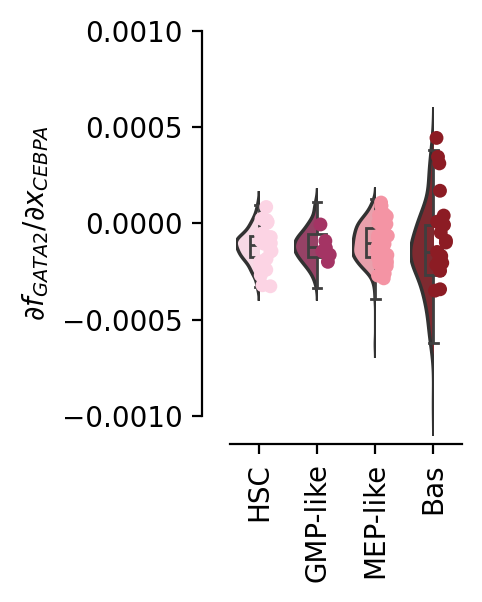

In [40]:
%matplotlib inline
fig,ax=plt.subplots(1,1,figsize = (1.5,2.5))
target='GATA2'
source='CEBPA'
adata1=adata_labeling[adata_labeling.obs['cell_type'].isin(['Bas','MEP-like','GMP-like','HSC'])]
adata1.obs['cell_type']=adata1.obs['cell_type'].cat.reorder_categories(['HSC','GMP-like','MEP-like','Bas'])
adata1.uns['cell_type_colors']=[color_dict[i] for i in adata1.obs['cell_type'].cat.categories]
violin_box(adata1,
           keys=f"jacobian_{target}_{source}",
           groupby='cell_type',ax=ax,show=False,
          max_strip_points=100)
ax.set_ylabel(r"$\partial f_{%s} / \partial x_{%s}$" % (target, source))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))
plt.xticks(rotation=90)
plt.xlabel('')
plt.ylim(-0.001,0.001)
fig.savefig(f'figures/fig4/violin_jacobian_{target}_{source}.png', dpi=300, bbox_inches='tight')

In [60]:
source_genes

array(['SPI1', 'RUNX1', 'GATA2', 'CEBPA'], dtype='<U5')

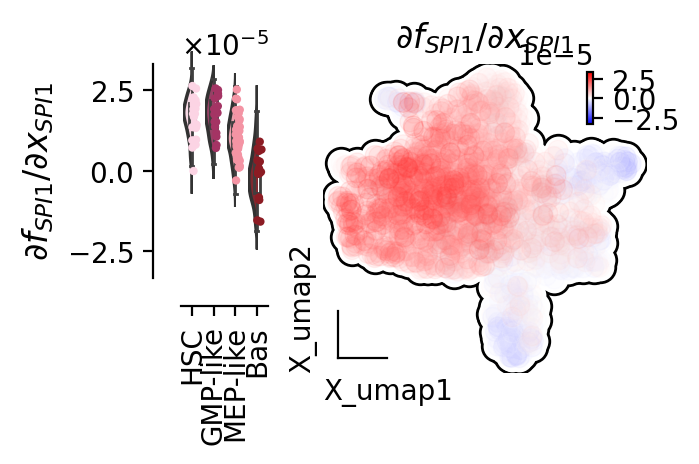

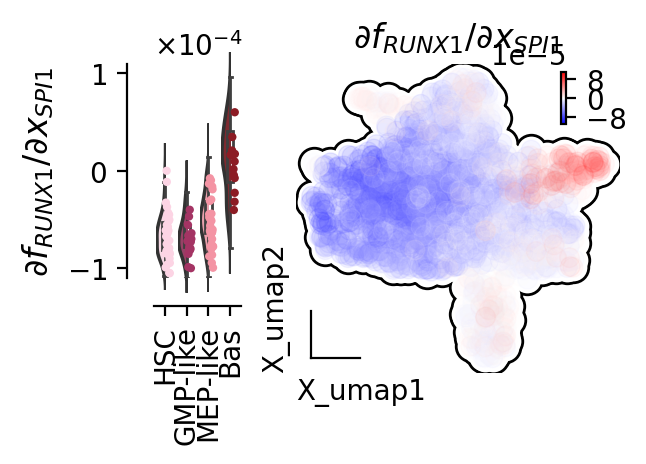

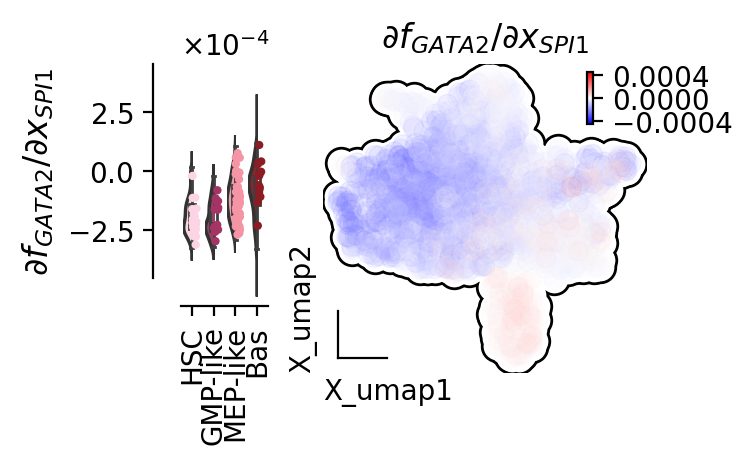

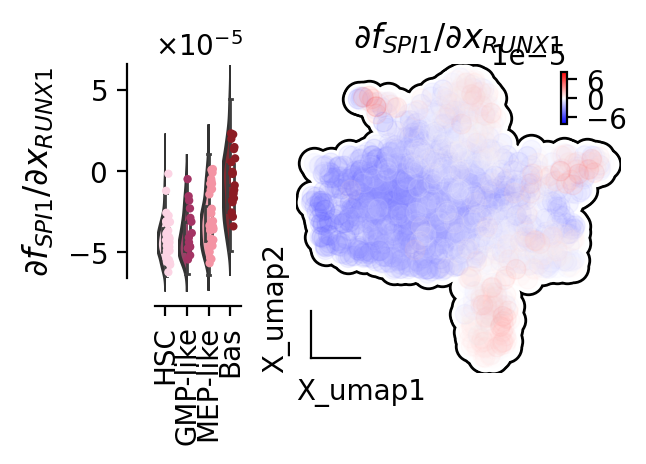

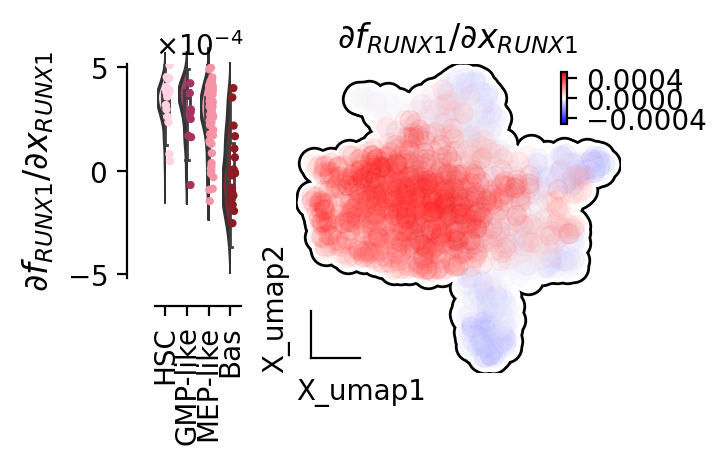

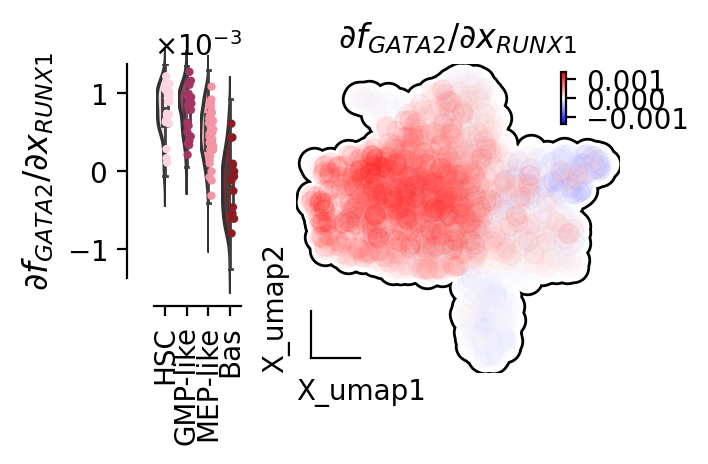

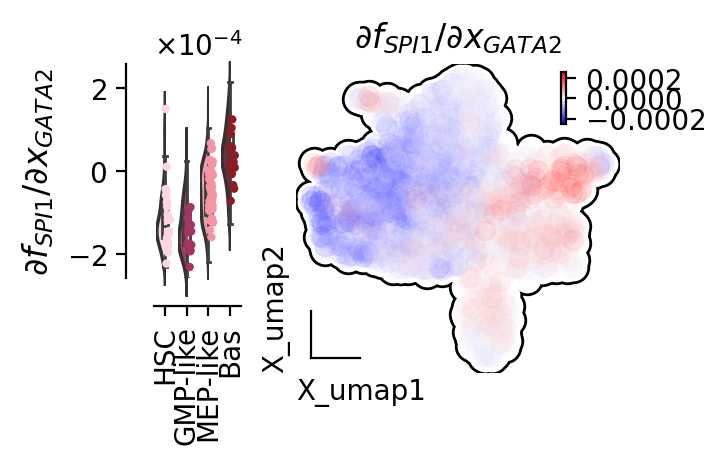

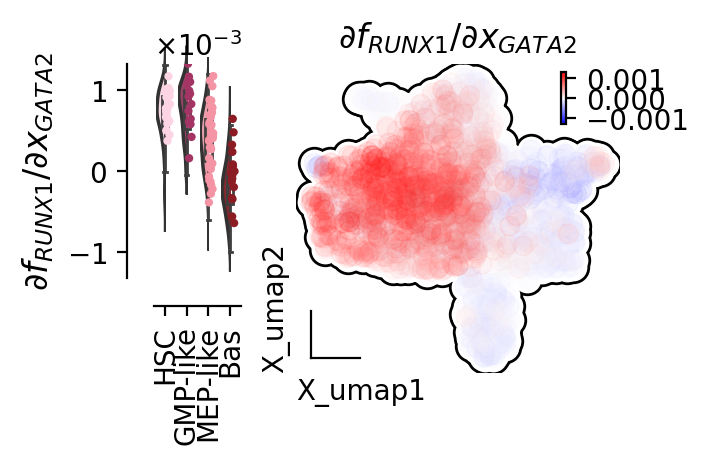

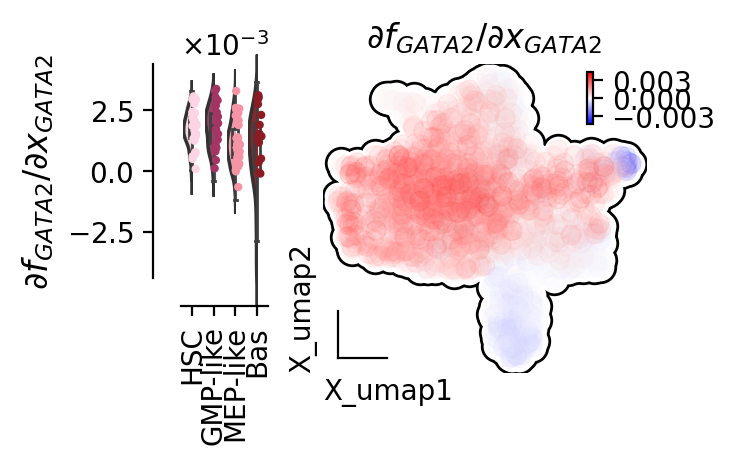

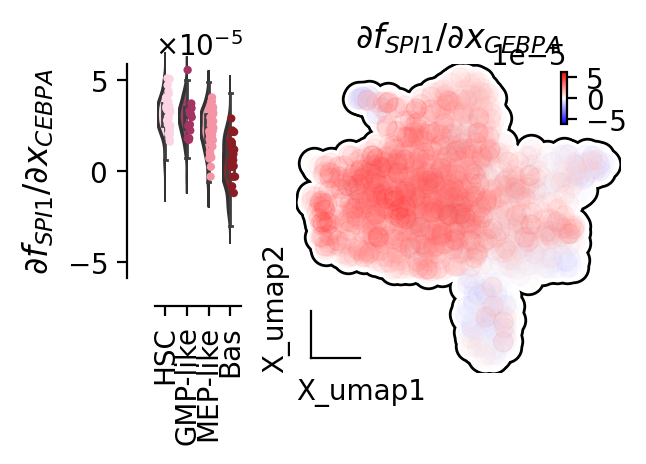

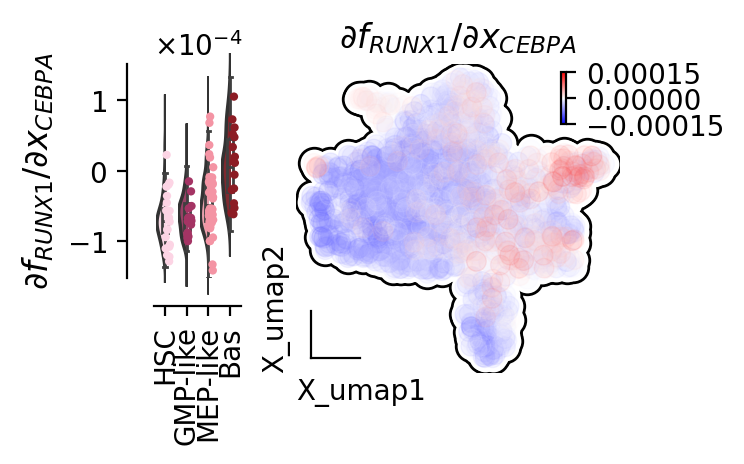

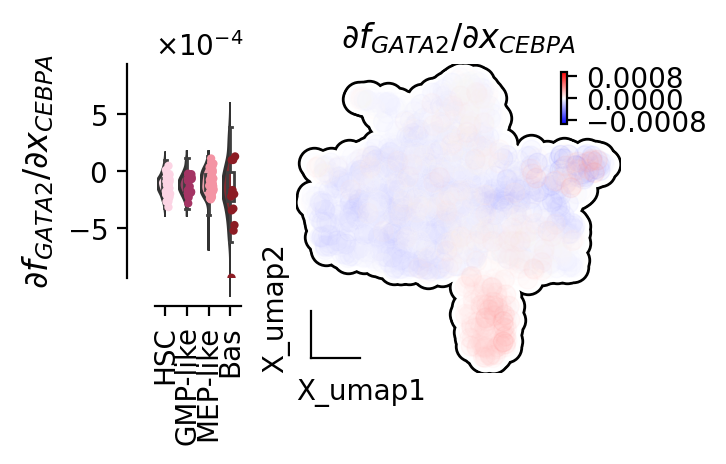

In [120]:
%matplotlib inline
from matplotlib import patheffects
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import numpy as np

for i, source in enumerate(source_genes):
    for j, target in enumerate(target_genes):
        fig = plt.figure(figsize=(3, 2))
        gs = gridspec.GridSpec(10, 10)
        
        # 第一个子图
        ax1 = fig.add_subplot(gs[:, 3:])
        v_max = np.max(np.abs(adata_labeling.obs[f"jacobian_{target}_{source}"]))
        dyn.pl.scatters(adata_labeling, color=[f"jacobian_{target}_{source}"], 
                               #color_key=color_dict,
                               #title='DG:CellType',
                               basis='umap', 
                               linewidth=0.5,
                               vmin=-v_max,
                                vmax=v_max,
                                cmap='bwr',s=50,
                                frontier=True,
                              save_show_or_return='return',ax=ax1)
        ax1.set_title(r"$\partial f_{%s} / \partial x_{%s}$" % (target, source),fontsize=12)

        ax=ax1
        coords=adata_labeling.obsm['X_umap']
        xmin=coords[:, 0].min()
        xmax=coords[:, 0].max()
        ymin=coords[:, 1].min()
        ymax=coords[:, 1].max()
        
        #ax.spines['left'].set_position(('outward', 10))
        #ax.spines['bottom'].set_position(('axes', 0))
        ax.spines['left'].set_position(('data', xmin))
        ax.spines['bottom'].set_position(('data', ymin))
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines["bottom"].set_visible(True)
        ax.spines["left"].set_visible(True)
        
        ax.get_xaxis().set_visible(True)
        ax.get_yaxis().set_visible(True)
        ax.set_yticks([])
        ax.set_xticks([])
        ax.spines['bottom'].set_bounds(xmin,xmin+(xmax-xmin)/6)
        ax.spines['left'].set_bounds(ymin,ymin+(ymax-ymin)/6)
        axis_labels=['X_umap1','X_umap2']
        ax.set_xlabel(axis_labels[0],loc='left',fontsize=10,)
        ax.set_ylabel(axis_labels[1],loc='bottom',fontsize=10)
        
        
        ax = fig.add_subplot(gs[:7, :2])
        adata1=adata_labeling[adata_labeling.obs['cell_type'].isin(['Bas','MEP-like','GMP-like','HSC'])]
        adata1.obs['cell_type']=adata1.obs['cell_type'].cat.reorder_categories(['HSC','GMP-like','MEP-like','Bas'])
        adata1.uns['cell_type_colors']=[color_dict[i] for i in adata1.obs['cell_type'].cat.categories]
        v_max = np.max(np.abs(adata1.obs[f"jacobian_{target}_{source}"]))
        violin_box(adata1,
                   keys=f"jacobian_{target}_{source}",
                   size=3,
                   groupby='cell_type',ax=ax,show=False,
                  max_strip_points=100)
        ax.set_ylabel(r"$\partial f_{%s} / \partial x_{%s}$" % (target, source),fontsize=12)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)
        ax.spines['left'].set_position(('outward', 10))
        ax.spines['bottom'].set_position(('outward', 10))
        # 设置y轴为科学计数法
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        plt.setp(ax.get_xticklabels(), rotation=90, fontsize=10)
        plt.setp(ax.get_yticklabels(), fontsize=10)
        
        ax.set_xlabel('')
        ax.set_ylim(-v_max,v_max)
        fig.tight_layout()
        
        fig.savefig(f'figures/fig4/multi_jacobian_{target}_{source}.png', dpi=300, bbox_inches='tight')
